In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import glob, sys, os

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from depth_keys.experiment.trial import Trial

SESSION_DIR     = REPO_ROOT / 'notebooks' / 'test_session'
CONFIG_PATH     = REPO_ROOT / 'notebooks' / 'config.toml'
INTRINSICS_FILE = Path('/storage/project/r-jmarkowitz30-0/shared/active_lab_members/markowitz_jeffrey/active_projects/mouse_open_field_lucid_rig_da_photometry/intrinsics_lucid_rig.toml')
SKELETON_JSON   = REPO_ROOT / 'notebooks' / 'skeleton.json'
TRANSFORMS_PATH = REPO_ROOT / 'notebooks' / 'avg_transforms.toml'

CENTROID = "/storage/home/hcoda1/3/triesenmy3/lab_folder/sleap_nn_models/models/centroid_unet"
CI = '/storage/home/hcoda1/3/triesenmy3/lab_folder/sleap_nn_models/models/convnext-large_seed-4'

REFERENCE_CAMERA = 'Lucid Vision Labs-HTP003S-001-224500508'
VERSION_NUM      = 1
CABLE            = False
CONDA_ENV_NAME   = 'sleap-nn-env'

NODE_NAMES = [
    'tail_tip', 'tail_middle', 'tail_base', 'back_bottom',
    'back_middle_lower', 'back_middle_upper', 'back_top',
    'left_ear', 'right_ear', 'snout',
    'left_hip', 'right_hip', 'left_shoulder', 'right_shoulder',
]

video_paths = sorted(glob.glob(str(SESSION_DIR / '_proc' / '*.avi')))

INFERENCE_OUTPUT_PATH = SESSION_DIR / '_proc' / f'_keypoints_v{VERSION_NUM}'
KEYPOINTS_OUTPUT_PATH = SESSION_DIR / '_proc' / f'_kpoints_v{VERSION_NUM}_3d'
RENDERS_OUTPUT_PATH   = SESSION_DIR / '_proc' / 'renders'

RENDERS_OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

print(f'Session: {SESSION_DIR}')
print(f'Videos found: {len(video_paths)}')

Session: /storage/project/r-jmarkowitz30-0/triesenmy3/depth_and_da/depth_keys/notebooks/test_session
Videos found: 3


In [3]:
trial = Trial(
    trial_id=SESSION_DIR.name,
    video_paths=video_paths,
    version_num=VERSION_NUM,
    base_dir=str(SESSION_DIR.parent),
    node_names=NODE_NAMES,
    video_extension='.avi',
    inference_output_path=str(INFERENCE_OUTPUT_PATH),
    keypoints_output_path=str(KEYPOINTS_OUTPUT_PATH),
    reference_camera=REFERENCE_CAMERA,
    intrinsics_file=str(INTRINSICS_FILE),
    cable=CABLE,
    conda_env_name=CONDA_ENV_NAME,
    transforms_path=TRANSFORMS_PATH,
)

In [4]:
# process_session: 2D keypoint prediction
trial.predict_keypoints(ci_model_path=CI, centroid_model_path=CENTROID)

Predicting... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 6000/6000 ETA: 0:00:00 Elapsed: 0:09:22 10.8 FPS

2026-05-08 15:32:03 | INFO | sleap_nn.predict:run_inference:497 | Finished inference at: 2026-05-08 15:32:03.155294
2026-05-08 15:32:03 | INFO | sleap_nn.predict:run_inference:498 | Total runtime: 569.2706568241119 secs
2026-05-08 15:32:03 | INFO | sleap_nn.predict:run_inference:512 | Predictions output path: /storage/project/r-jmarkowitz30-0/triesenmy3/depth_and_da/depth_keys/notebooks/test_session/_proc/_keypoints_v1/Lucid Vision Labs-HTP003S-001-224500508.slp
2026-05-08 15:32:03 | INFO | sleap_nn.predict:run_inference:513 | Saved file at: 2026-05-08 15:32:03.814402


In [5]:
# post_process: 2D -> 3D conversion
trial.compute_3d_keypoints(config_path=str(CONFIG_PATH))

-> /storage/project/r-jmarkowitz30-0/triesenmy3/depth_and_da/depth_keys/notebooks/test_session/_proc/Lucid Vision Labs-HTP003S-001-223702048.avi
-> /storage/project/r-jmarkowitz30-0/triesenmy3/depth_and_da/depth_keys/notebooks/test_session/_proc/Lucid Vision Labs-HTP003S-001-223702266.avi
-> /storage/project/r-jmarkowitz30-0/triesenmy3/depth_and_da/depth_keys/notebooks/test_session/_proc/Lucid Vision Labs-HTP003S-001-224500508.avi


  0%|          | 0/3 [00:00<?, ?it/s]

Processing files to get 3D keypoints...
3 jobs to process


[Parallel(n_jobs=-1)]: Using backend MultiprocessingBackend with 6 concurrent workers.
[Parallel(n_jobs=-1)]: Done 3 out of 3 | elapsed:  2.1min finished


Loaded post-processing params from /storage/project/r-jmarkowitz30-0/triesenmy3/depth_and_da/depth_keys/notebooks/config.toml
Using transforms from file: /storage/project/r-jmarkowitz30-0/triesenmy3/depth_and_da/depth_keys/notebooks/avg_transforms.toml
Applying post processing...


/storage/project/r-jmarkowitz30-0/triesenmy3/markovids/src/markovids/pcl/post_processing.py:153: RuntimeWarning: All-NaN slice encountered
  extracted_confidence = np.nanmax(merged_conf[:, keypoint_indices], axis=-1)


  0%|          | 0/14 [00:00<?, ?it/s]

Bone tail_tip        -> tail_middle    :  40.29 ±  1.93 mm (n=5728, outliers removed: 635)
Bone tail_middle     -> tail_base      :  36.08 ±  1.53 mm (n=5975, outliers removed: 831)
Bone back_middle_lower -> back_middle_upper:  15.71 ±  1.29 mm (n=5994, outliers removed: 889)
Bone back_middle_upper -> back_top       :  13.89 ±  1.67 mm (n=5935, outliers removed: 361)
Bone left_ear        -> right_ear      :  26.65 ±  2.27 mm (n=5904, outliers removed: 457)
Bone left_shoulder   -> right_shoulder :  23.32 ±  1.58 mm (n=5961, outliers removed: 171)
Bone left_hip        -> right_hip      :  28.37 ±  1.47 mm (n=6000, outliers removed: 730)
Bone back_top        -> left_shoulder  :  13.51 ±  1.11 mm (n=5913, outliers removed: 492)
Bone back_top        -> right_shoulder :  13.28 ±  1.62 mm (n=5934, outliers removed: 206)
Bone back_bottom     -> left_hip       :  19.38 ±  1.62 mm (n=6000, outliers removed: 646)
Bone back_bottom     -> right_hip      :  20.03 ±  1.36 mm (n=6000, outliers removed

Visualizing keypoints from: /storage/project/r-jmarkowitz30-0/triesenmy3/depth_and_da/depth_keys/notebooks/test_session/_proc/_kpoints_v1_3d/merged_keypoints.h5
Output target: /storage/project/r-jmarkowitz30-0/triesenmy3/depth_and_da/depth_keys/notebooks/test_session/_proc/renders
Rendering 3D visualization to /storage/project/r-jmarkowitz30-0/triesenmy3/depth_and_da/depth_keys/notebooks/test_session/_proc/renders/matplotlib_render.mp4...


  0%|          | 0/5990 [00:00<?, ?it/s]

Visualization complete.
Processing session: test_session
Loading keypoints from: /storage/project/r-jmarkowitz30-0/triesenmy3/depth_and_da/depth_keys/notebooks/test_session/_proc/_kpoints_v1_3d/merged_keypoints.h5
Loaded 6000 frames of keypoint data
Found video file: /storage/project/r-jmarkowitz30-0/triesenmy3/depth_and_da/depth_keys/notebooks/test_session/_proc/Lucid Vision Labs-HTP003S-001-224500508.avi
Video has 6000 frames
Keypoint data has 6000 frames
Using 6000 frames
Z-range: 251.98 to 410.91
Loading frames 0 to 1...
Loaded 480 frames of size (480, 640)
Creating video with keypoint overlays...
Output video will be saved to: /storage/project/r-jmarkowitz30-0/triesenmy3/depth_and_da/depth_keys/notebooks/test_session/_proc/renders/keypoints_overlay_v1.mp4
Processing batch 0-500 of 6000 frames...
Loading frames 0 to 500...
Loaded 500 frames of size (480, 640)
Wrote 500 frames (batch 0-499)
Processing batch 500-1000 of 6000 frames...
Loading frames 500 to 1000...
Loaded 500 frames o

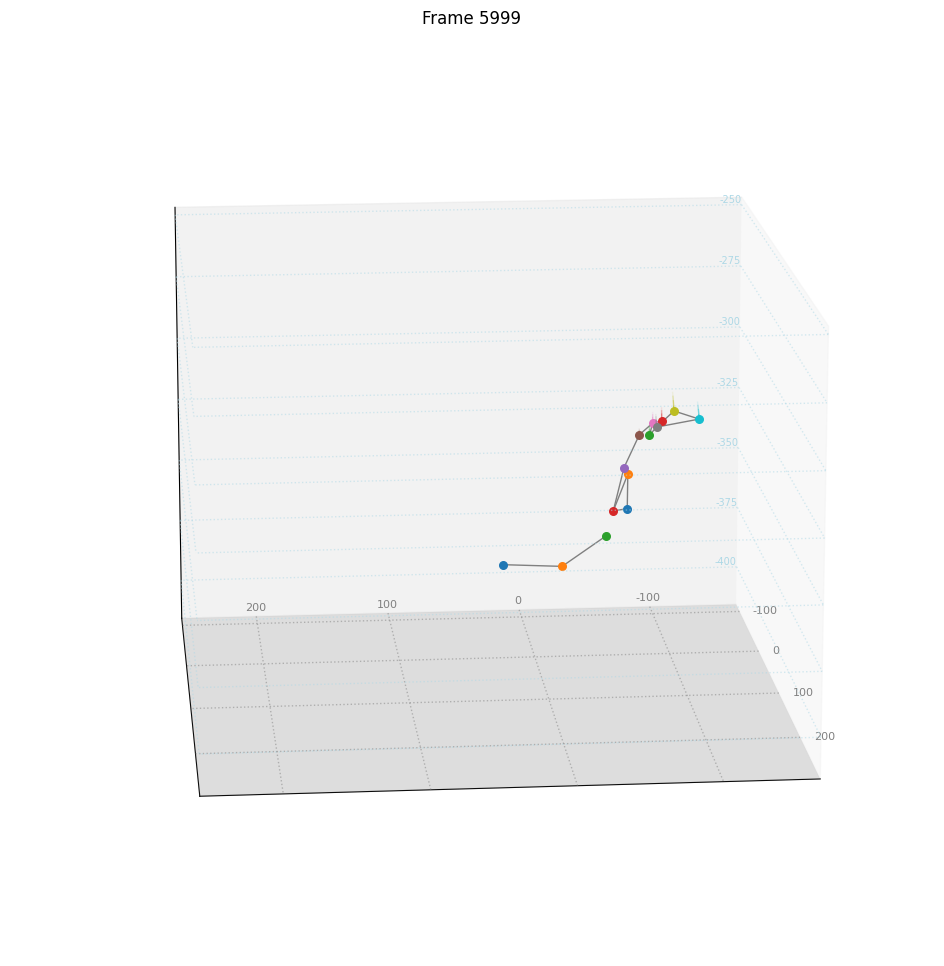

In [6]:
# visualize: render keypoint overlay + 3D matplotlib video
alt_key_path = os.path.join(trial.keypoints_output_path, 'merged_keypoints.h5')

trial.visualize(
    matplot_viz=True,
    overlay_viz=True,
    output_dir=str(RENDERS_OUTPUT_PATH),
    skeleton_json_path=str(SKELETON_JSON),
    alt_key_path=alt_key_path,
)

In [7]:
for p in [INFERENCE_OUTPUT_PATH, KEYPOINTS_OUTPUT_PATH, RENDERS_OUTPUT_PATH]:
    print(f'{p.name} -> {"exists" if p.exists() else "missing"}')

_keypoints_v1 -> exists
_kpoints_v1_3d -> exists
renders -> exists
